# DECISION TREES & RANDOM FORESTS

In this notebook, we explore tree-based machine learning algorithms using the Titanic dataset. We train and compare Decision Trees with different depths, investigate underfitting and overfitting, build a Random Forest classifier, and analyze feature importance.

## IMPORTING LIBRARIES

Import all required libraries for data manipulation, preprocessing, model training, evaluation, and visualization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

## LOADING THE TITANIC DATASET

Load the Titanic dataset and inspect its contents before preprocessing.

In [4]:
df = pd.read_csv("/Users/ayeshafaiz/ML_Internship/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## EXPLORATORY DATA INSPECTION

Check dataset dimensions, data types, and missing values.

In [5]:
print(df.shape)

df.info()

df.isnull().sum()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## DEFINING FEATURES AND TARGET VARIABLE

Separate the target variable from the feature set.

In [6]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

## IDENTIFYING NUMERICAL AND CATEGORICAL FEATURES

Automatically identify numerical and categorical columns for preprocessing.

In [7]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

categorical_cols = X.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

Categorical Columns:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')


## BUILDING THE PREPROCESSING PIPELINE

Create separate preprocessing pipelines for numerical and categorical features.

In [8]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

## COMBINING PREPROCESSING STEPS USING COLUMNTRANSFORMER

Combine numerical and categorical preprocessing into a single transformer.

In [9]:
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## TRAIN-TEST SPLIT

Split the dataset into training and testing sets using stratification.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## TRAINING DECISION TREE WITH MAX_DEPTH = 3

Build a shallow Decision Tree to study underfitting behavior.

In [11]:
tree3 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ))
])

tree3.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['PassengerId','Pclass','Name',...,'Fare','Cabin','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

## EVALUATING DECISION TREE (DEPTH = 3)

Measure training and testing accuracy for the shallow tree.

In [12]:
train_acc_3 = tree3.score(X_train, y_train)
test_acc_3 = tree3.score(X_test, y_test)

print("Train Accuracy:", train_acc_3)
print("Test Accuracy:", test_acc_3)

Train Accuracy: 0.8342696629213483
Test Accuracy: 0.7821229050279329


## TRAINING DECISION TREE WITH MAX_DEPTH = 10

Build a deeper Decision Tree to study model complexity.

In [13]:
tree10 = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ))
])

tree10.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['PassengerId','Pclass','Name',...,'Fare','Cabin','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

## EVALUATING DECISION TREE (DEPTH = 10)

Measure training and testing accuracy for the deeper tree.

In [14]:
train_acc_10 = tree10.score(X_train, y_train)
test_acc_10 = tree10.score(X_test, y_test)

print("Train Accuracy:", train_acc_10)
print("Test Accuracy:", test_acc_10)

Train Accuracy: 0.9536516853932584
Test Accuracy: 0.7653631284916201


## COMPARING UNDERFITTING AND OVERFITTING

Compare shallow and deep Decision Trees to understand model complexity.

In [15]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree (Depth=3)",
              "Decision Tree (Depth=10)"],
    "Train Accuracy": [train_acc_3, train_acc_10],
    "Test Accuracy": [test_acc_3, test_acc_10]
})

comparison

,Model,Train Accuracy,Test Accuracy
0,Decision Tree (Depth=3),0.834270,0.782123
1,Decision Tree (Depth=10),0.953652,0.765363


## VISUALIZING THE DECISION TREE

Visualize the structure of the shallow Decision Tree model.

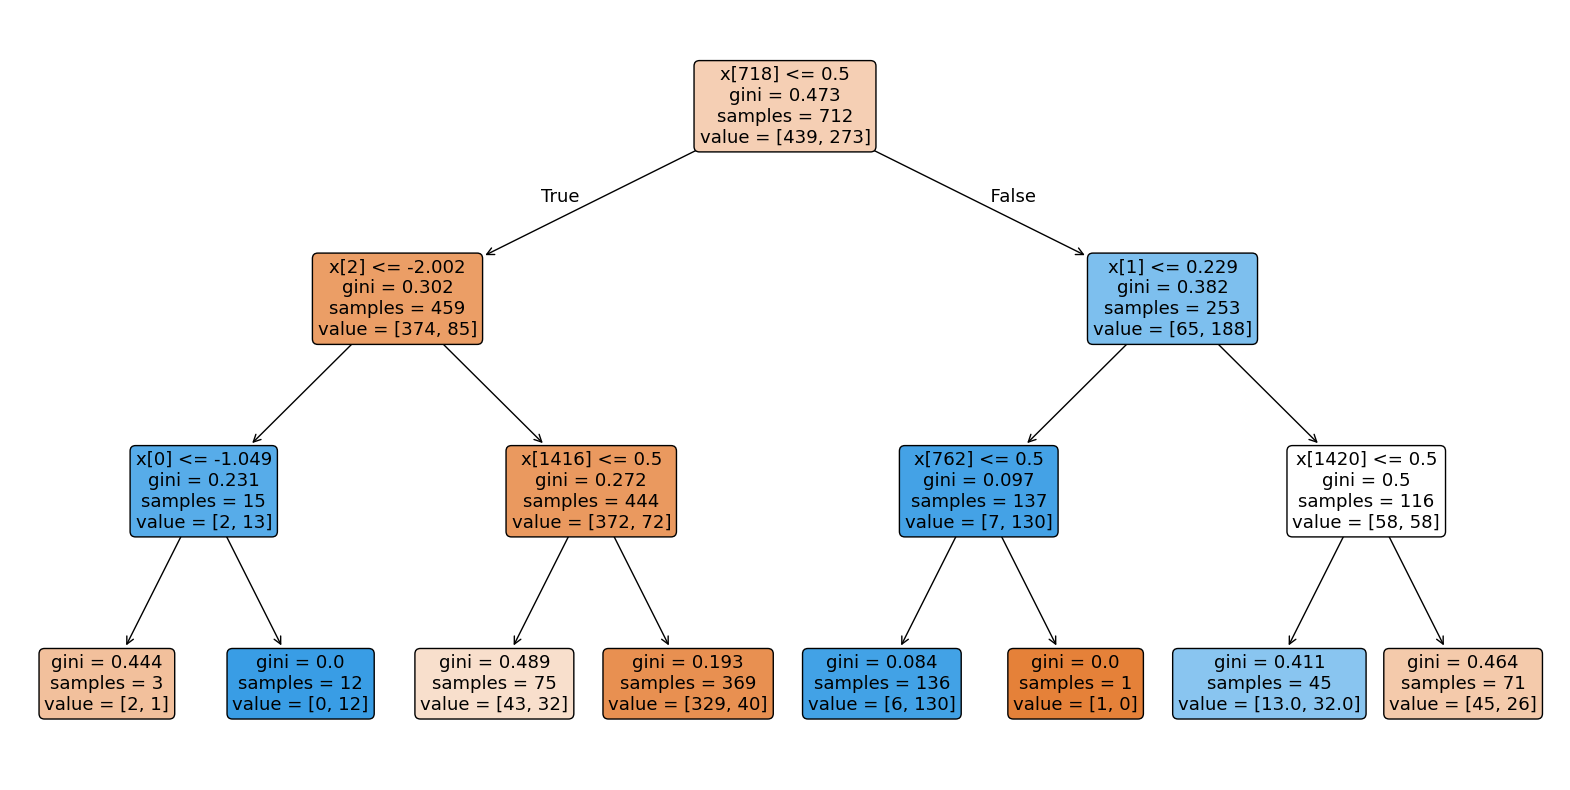

In [16]:
X_train_transformed = preprocessor.fit_transform(X_train)

clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train_transformed, y_train)

plt.figure(figsize=(20,10))

plot_tree(
    clf,
    filled=True,
    rounded=True
)

plt.show()

## TRAINING THE RANDOM FOREST MODEL

Build a Random Forest classifier using 100 decision trees.

In [17]:
rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['PassengerId','Pclass','Name',...,'Fare','Cabin','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

## EVALUATING THE RANDOM FOREST MODEL

Measure training and testing accuracy of the Random Forest model.

In [18]:
rf_train_acc = rf.score(X_train, y_train)
rf_test_acc = rf.score(X_test, y_test)

print("Train Accuracy:", rf_train_acc)
print("Test Accuracy:", rf_test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.8100558659217877


## EXTRACTING FEATURE IMPORTANCE

Retrieve feature importance scores from the trained Random Forest model.

In [19]:
feature_importances = rf.named_steps[
    "classifier"
].feature_importances_

## VISUALIZING THE TOP 10 MOST IMPORTANT FEATURES

Display the most influential features learned by the Random Forest.

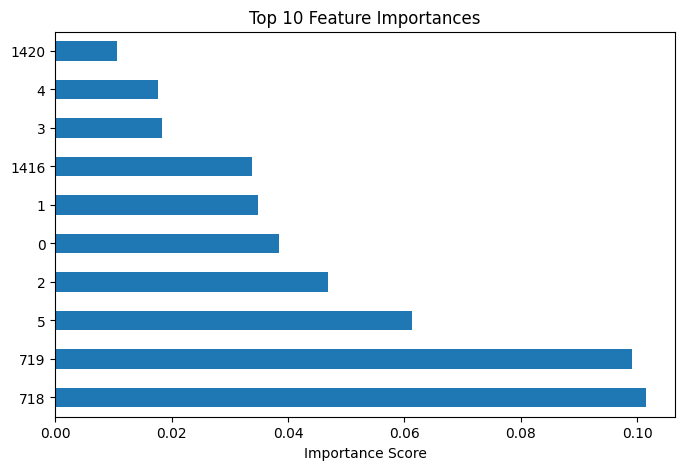

In [20]:
top_features = pd.Series(feature_importances)

top_features.nlargest(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.show()

## MODEL PERFORMANCE SUMMARY

Compare Decision Trees and Random Forest performance.

In [21]:
summary = pd.DataFrame({
    "Model": [
        "Decision Tree (Depth=3)",
        "Decision Tree (Depth=10)",
        "Random Forest"
    ],
    "Train Accuracy": [
        train_acc_3,
        train_acc_10,
        rf_train_acc
    ],
    "Test Accuracy": [
        test_acc_3,
        test_acc_10,
        rf_test_acc
    ]
})

summary

,Model,Train Accuracy,Test Accuracy
0,Decision Tree (Depth=3),0.834270,0.782123
1,Decision Tree (Depth=10),0.953652,0.765363
2,Random Forest,1.000000,0.810056


## CONCLUSION

In this notebook, we implemented and evaluated Decision Tree and Random Forest classifiers on the Titanic dataset. Two Decision Tree models with depths of 3 and 10 were trained to analyze the effects of model complexity. The shallow tree provided simpler decision boundaries, while the deeper tree achieved higher training accuracy but showed signs of overfitting.

A Random Forest classifier consisting of 100 decision trees was then trained and evaluated. The Random Forest achieved the best overall performance by reducing overfitting and improving generalization on unseen data. Feature importance analysis revealed the most influential variables contributing to passenger survival predictions.

Overall, this experiment demonstrated the strengths and limitations of Decision Trees and highlighted how ensemble methods such as Random Forests can significantly improve predictive performance and model robustness.